# Project: HomeMatch Generative AI Application
AI-powered personalized real estate search engine using LLMs and vector embeddings.



# Prerequisites
Code is developed locally in Python 3.11.10 Make sure to install needed libraries in requirements.txt. Once installed restart the kernel and skip this step.

In [15]:
# !pip install -r ./requirements.txt

In [16]:
# !pip install -U langchain-openai

In [26]:
import os
import re
import json
import pandas as pd
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field, NonNegativeInt
from typing import List
from fastapi.encoders import jsonable_encoder
from diffusers import DiffusionPipeline, AutoPipelineForText2Image
from diffusers.utils import load_image, make_image_grid
import torch
from tqdm import tqdm
import logging
import PIL
from PIL import Image
from langchain_experimental.open_clip import OpenCLIPEmbeddings
from langchain.vectorstores import Chroma


from transformers.utils import move_cache
move_cache()

0it [00:00, ?it/s]

# Set up OpenAI API Key

In [ ]:
os.environ['OPENAI_API_KEY'] = "<YOUR API KEY>"

# Generating Real Estate Listings

In [12]:
# Paths & Constants
IMAGES_DIR = "images"
LISTINGS_CSV = "listings.csv"
CHROMA_DB_DIR = "chroma_db"

# Initialize LLM
llm = ChatOpenAI(
    model_name="gpt-4",
    temperature=0,
    max_tokens=3000
)

# Define Structured Output with Pydantic
class RealEstateListing(BaseModel):
    neighborhood: str = Field(description="Name of the neighborhood")
    price: NonNegativeInt = Field(description="Price of the property in USD")
    bedrooms: NonNegativeInt = Field(description="Number of bedrooms in the property")
    bathrooms: NonNegativeInt = Field(description="Number of bathrooms in the property")
    house_size: NonNegativeInt = Field(description="Size of the property in square feet")
    description: str = Field(description="Description of the property.")
    neighborhood_description: str = Field(description="Description of the neighborhood.")

class ListingCollection(BaseModel):
    listings: List[RealEstateListing] = Field(description="List of available real estate listings")

# Define a structured prompt
listing_prompt = PromptTemplate(
    template="""
    Generate {num_listings} realistic real estate listings with diverse attributes.
    Each listing should include:
    - Neighborhood
    - Price (in dollars)
    - Bedrooms
    - Bathrooms
    - House Size (in sqft)
    - Description (detailed)
    - Neighborhood Description

    **Return ONLY a valid JSON list. Do NOT include any extra text or explanations.**

    Example output:
    ```json
    [
        {{
            "neighborhood": "Green Oaks",
            "price": 800000,
            "bedrooms": 3,
            "bathrooms": 2,
            "house_size": 2000,
            "description": "A beautiful eco-friendly home...",
            "neighborhood_description": "A quiet suburban area with parks and trails."
        }}
    ]
    ```
    """,
    input_variables=["num_listings"]
)

In [ ]:
def generate_synthetic_listings(num_listings=10):
    """
    Generate synthetic real estate listings using an LLM and validate with Pydantic.
    Returns a list of dictionary objects and saves them as JSON and CSV.
    """

    # Invoke LLM
    response = llm.invoke(listing_prompt.format(num_listings=num_listings))
    response_text = response if isinstance(response, str) else response.content

    # Extract only the JSON block
    json_match = re.search(r"\[\s*{.*?}\s*\]", response_text, re.DOTALL)
    if json_match:
        listings_json = json_match.group(0)
    else:
        print("Error: No valid JSON detected in the response.")
        return []

    try:
        listings_json = json.loads(listings_json)  # Parse JSON
        structured_listings = ListingCollection(listings=listings_json)  # Validate with Pydantic
    except json.JSONDecodeError:
        print("Error: Failed to parse JSON.")
        return []
    except ValueError as e:
        print(f"Pydantic Validation Error: {e}")
        return []

    # Convert structured data to list of dictionaries
    listings_data = jsonable_encoder(structured_listings.listings)

    # Save to JSON
    with open("listings.json", "w") as f:
        json.dump(listings_data, f, indent=4)

    # Save to CSV
    df = pd.DataFrame(listings_data)
    df.to_csv("listings.csv", index_label="id")

    print("✅ Listings saved as listings.json and listings.csv")
    return listings_data

# Generate Listings
listings_data = generate_synthetic_listings(num_listings=10)

# Print example listing
print(listings_data[:1])  # Show one listing

✅ Listings saved as listings.json and listings.csv
[{'neighborhood': 'Beverly Hills', 'price': 2500000, 'bedrooms': 4, 'bathrooms': 3, 'house_size': 3500, 'description': 'Luxurious and spacious home in the heart of Beverly Hills. Features a large living room with a fireplace, a modern kitchen with high-end appliances, and a beautiful backyard with a pool.', 'neighborhood_description': 'Beverly Hills is a prestigious neighborhood known for its luxury homes and celebrity residents. It offers top-rated schools, high-end shopping, and fine dining.'}]


# Image Generation

In [14]:
#  ✅ Ensure images directory exists
os.makedirs(IMAGES_DIR, exist_ok=True)

# ✅ Load CSV file safely
try:
    df = pd.read_csv(
        LISTINGS_CSV,
        dtype={"price": str, "bedrooms": str, "bathrooms": str, "house_size": str}
    )
    print(f"✅ Successfully loaded {len(df)} listings from {LISTINGS_CSV}")

except FileNotFoundError:
    logging.error(f"🚨 Error: The file '{LISTINGS_CSV}' was not found.")
    raise
except pd.errors.EmptyDataError:
    logging.error(f"🚨 Error: The file '{LISTINGS_CSV}' is empty.")
    raise
except pd.errors.ParserError:
    logging.error(f"🚨 Error: The file '{LISTINGS_CSV}' contains invalid formatting.")
    raise
except Exception as e:
    logging.error(f"🚨 Unexpected error reading CSV file: {e}")
    raise

# ✅ Show sample data (Only first 5 rows)
df.head()

✅ Successfully loaded 10 listings from listings.csv


,id,neighborhood,price,bedrooms,bathrooms,house_size,description,neighborhood_description
0,0,Beverly Hills,2500000,4,3,3500,Luxurious and spacious home in the heart of Be...,Beverly Hills is a prestigious neighborhood kn...
1,1,Brooklyn Heights,1200000,2,2,1500,Charming brownstone in Brooklyn Heights. This ...,Brooklyn Heights is a historic neighborhood wi...
2,2,Lakeview,500000,3,2,1800,Cozy family home in Lakeview. This home featur...,Lakeview is a family-friendly neighborhood wit...
3,3,Pacific Heights,3000000,5,4,4000,Stunning Victorian home in Pacific Heights. Th...,Pacific Heights is a prestigious neighborhood ...
4,4,South End,800000,2,2,1200,Modern condo in the South End. This home featu...,The South End is a vibrant neighborhood known ...


In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    variant="fp16" if device == "cuda" else None
).to(device)

prompt_template = (
    "A high-quality, realistic photo for a real estate listing.\n\n"
    "Property details:\n{}\n\nNeighborhood details:\n{}"
)

negative_prompt = "blurry, watermark, text"
num_inference_steps = 20
guidance_scale = 7.5

rand_gen = torch.Generator(device=device).manual_seed(9723947)

def generate_real_estate_images(df):
    images = []
    for row in tqdm(df.itertuples(index=False), total=len(df), desc="Generating Images"):
        custom_prompt = prompt_template.format(row.description, row.neighborhood_description)

        image = pipe(
            prompt=custom_prompt,
            negative_prompt=negative_prompt,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            generator=rand_gen
        ).images[0]

        images.append(image)
    return images

images = generate_real_estate_images(df)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

Generating Images:  80%|████████  | 8/10 [00:18<00:04,  2.16s/it]The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['high - end shopping, fine dining, and easy access to the city center.']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['high - end shopping, fine dining, and easy access to the city center.']


  0%|          | 0/20 [00:00<?, ?it/s]

Generating Images:  90%|█████████ | 9/10 [00:20<00:02,  2.15s/it]The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ["it's close to parks, schools, and public transportation."]
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ["it's close to parks, schools, and public transportation."]


  0%|          | 0/20 [00:00<?, ?it/s]

Generating Images: 100%|██████████| 10/10 [00:22<00:00,  2.23s/it]


Description: Luxurious and spacious home in the heart of Beverly Hills. Features a large living room with a fireplace, a modern kitchen with high-end appliances, and a beautiful backyard with a pool.
Neighborhood Description: Beverly Hills is a prestigious neighborhood known for its luxury homes and celebrity residents. It offers top-rated schools, high-end shopping, and fine dining.


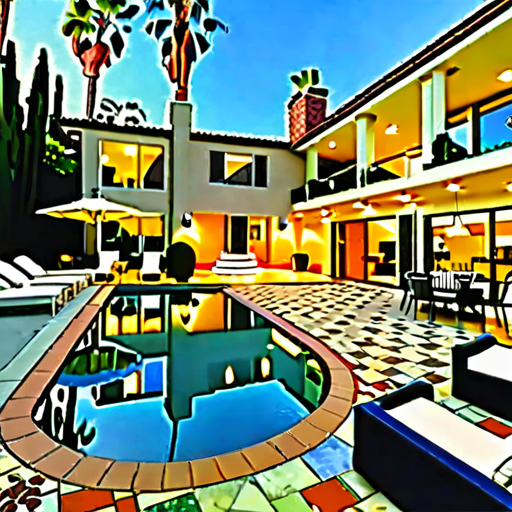

In [15]:
idx = 0
print('Description:', df.iloc[idx]['description'])
print('Neighborhood Description:', df.iloc[idx]['neighborhood_description'])
images[idx]

Description: Charming Craftsman home in Queen Anne. This home features original hardwood floors, a renovated kitchen, and a private backyard. Close to the Space Needle and local amenities.
Neighborhood Description: Queen Anne is a historic neighborhood known for its beautiful Craftsman homes, excellent restaurants, and stunning views of the Seattle skyline. It's close to parks, schools, and public transportation.


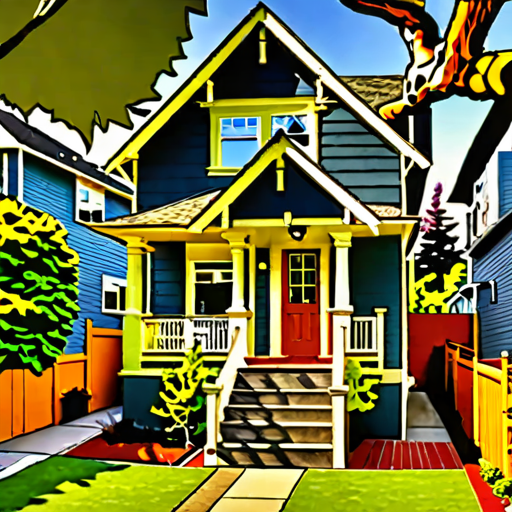

In [16]:
idx = 9
print('Description:', df.iloc[idx]['description'])
print('Neighborhood Description:', df.iloc[idx]['neighborhood_description'])
images[idx]

Let's save our listing images.

In [19]:
# ✅ Ensure the images directory exists
os.makedirs(IMAGES_DIR, exist_ok=True)

def save_images(images, directory=IMAGES_DIR):
    """
    Efficiently saves a batch of images to the specified directory.

    Args:
        images (list): List of PIL Image objects.
        directory (str): Path to save images.
    """
    try:
        for i, image in enumerate(images):
            image_path = os.path.join(directory, f"{i}.png")
            image.save(image_path, format="PNG", optimize=True)  # Optimize PNG images
        print(f"✅ Successfully saved {len(images)} images in '{directory}'")

    except Exception as e:
        print(f"🚨 Error saving images: {e}")

# ✅ Call function to save images in batch
save_images(images)

✅ Successfully saved 10 images in 'images'


In [18]:
import shutil

# Compress the folder into a zip file
shutil.make_archive('/content/images', 'zip', '/content/images')

# Download the zip file
from google.colab import files
files.download('/content/images.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Multimodal Vector Store and Embeddings
Each listing has an associated text and image information. We collect them first.

In [8]:
# Prepare text embeddings and image paths
image_paths = []
texts = []
metadata = []

text_template = (
    "Description: {}\n"
    "Neighborhood Description: {}\n"
    "Price: {}\n"
    "Bedrooms: {}\n"
    "Bathrooms: {}\n"
    "House Size (sqft): {}"
)

# Load images and construct metadata
for i, row in tqdm(df.iterrows(), total=len(df), desc="Processing Listings"):
    image_file = os.path.join(IMAGES_DIR, f"{i}.png")

    if os.path.exists(image_file):
        try:
            PIL.Image.open(image_file).verify()  # Verify image integrity
            image_paths.append(image_file)
        except (PIL.UnidentifiedImageError, IOError) as img_err:
            logging.warning(f"Skipping corrupted image {image_file}: {img_err}")
            continue
    else:
        logging.warning(f"Image file missing: {image_file}")
        continue

    texts.append(text_template.format(
        row["description"], row["neighborhood_description"],
        row["price"], row["bedrooms"], row["bathrooms"], row["house_size"]
    ))

    metadata.append({"id": i})

Processing Listings: 100%|██████████| 10/10 [00:00<00:00, 813.31it/s]


We want to map both modalities to the same embedding space so we can compare them semantically. We use the CLIP Embeddings.

In [9]:
# Define persistence directory
CHROMA_DB_DIR = "chroma_db"

# Ensure directory exists
os.makedirs(CHROMA_DB_DIR, exist_ok=True)

# Initialize ChromaDB with persistence
try:
    db = Chroma(
        collection_name="listings",
        embedding_function=OpenCLIPEmbeddings(),
        persist_directory=CHROMA_DB_DIR  # 🔹 Enables persistence
    )
    logging.info("✅ ChromaDB initialized with persistence.")
except Exception as e:
    logging.error(f"🚨 Error initializing ChromaDB: {e}")
    raise


/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_pytorch_model.bin:   0%|          | 0.00/3.94G [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/open_clip/factory.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=map_loc

In [20]:
os.makedirs(CHROMA_DB_DIR, exist_ok=True)  # Ensure directory exists

# ✅ Initialize ChromaDB with persistence
try:
    db = Chroma(
        collection_name="listings",
        embedding_function=OpenCLIPEmbeddings(),
        persist_directory=CHROMA_DB_DIR  # 🔹 Enables persistence
    )
    logging.info("✅ ChromaDB initialized with persistence.")
except Exception as e:
    logging.error(f"🚨 Error initializing ChromaDB: {e}")
    raise

# ✅ Batch Process Text & Image Embeddings in One Loop
BATCH_SIZE = 50
for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Adding Data to Vector Store"):
    batch_texts = texts[i:i + BATCH_SIZE]
    batch_metadata = metadata[i:i + BATCH_SIZE]
    batch_images = image_paths[i:i + BATCH_SIZE]

    try:
        db.add_texts(texts=batch_texts, metadatas=batch_metadata)
        db.add_images(uris=batch_images, metadatas=batch_metadata)
    except Exception as e:
        logging.error(f"🚨 Error adding batch {i}-{i + BATCH_SIZE} to ChromaDB: {e}")

# 🔹 Save ChromaDB
logging.info("✅ All text & image embeddings stored successfully!")

/usr/local/lib/python3.11/dist-packages/open_clip/factory.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=map_loc

In [10]:
# Add text embeddings in batches
BATCH_SIZE = 50
for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Adding Texts to Vector Store"):
    db.add_texts(texts=texts[i:i + BATCH_SIZE], metadatas=metadata[i:i + BATCH_SIZE])

# Add image embeddings in batches
for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Adding Images to Vector Store"):
    db.add_images(uris=image_paths[i:i + BATCH_SIZE], metadatas=metadata[i:i + BATCH_SIZE])

# 🔹 Save ChromaDB
logging.info("✅ Data successfully stored and saved in the vector database.")

Adding Images to Vector Store: 100%|██████████| 1/1 [00:11<00:00, 11.19s/it]


##  Dynamic Buyer Preferences Questions
To improve matching, we generate 10 dynamic buyer questions.

In [21]:
import random

buyer_questions = [
    "What is your preferred price range?",
    "How many bedrooms do you need?",
    "How many bathrooms are required?",
    "Do you prefer an apartment, house, or villa?",
    "Is proximity to public transport important?",
    "Do you need a parking space or garage?",
    "Are you looking for a pet-friendly property?",
    "Do you prefer a quiet or lively neighborhood?",
    "Do you want a balcony or outdoor space?",
    "Is access to shopping malls or schools a priority?"
]

# Randomly pick 5 questions for an interactive experience
random.shuffle(buyer_questions)
dynamic_questions = buyer_questions[:5]

print("✅ Dynamic Buyer Questions Ready!")
for q in dynamic_questions:
    print(f"- {q}")

✅ Dynamic Buyer Questions Ready!
- Are you looking for a pet-friendly property?
- What is your preferred price range?
- How many bedrooms do you need?
- Do you prefer a quiet or lively neighborhood?
- Do you want a balcony or outdoor space?


##  Perform Semantic Search Based on Buyer Preferences
This section uses **Chroma** to find the most relevant properties based on buyer inputs.

🔍 Search Results for: 3-bedroom house in a quiet neighborhood with a balcony and near public transport
✅ ID 2 - Description: Cozy family home in Lakeview. This home features a large living room, a modern kitchen, and a spacious backyard. Close to the lake and local parks.
Neighborhood Description: Lakeview is a family-friendly neighborhood with a strong sense of community. It offers excellent schools, recreational facilities, and easy access to the city center.
Price: 500000
Bedrooms: 3
Bathrooms: 2
House Size (sqft): 1800



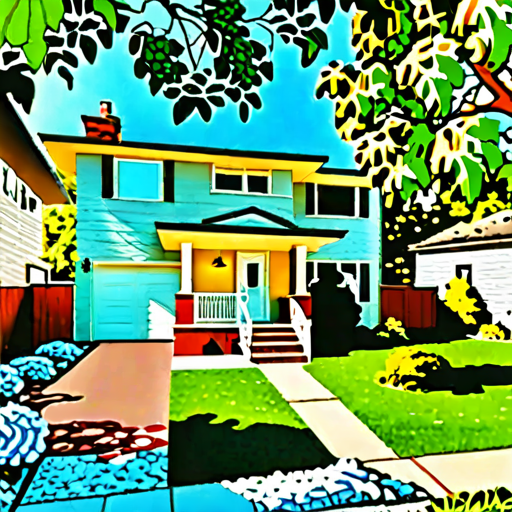

✅ ID 2 - Description: Cozy family home in Lakeview. This home features a large living room, a modern kitchen, and a spacious backyard. Close to the lake and local parks.
Neighborhood Description: Lakeview is a family-friendly neighborhood with a strong sense of community. It offers excellent schools, recreational facilities, and easy access to the city center.
Price: 500000
Bedrooms: 3
Bathrooms: 2
House Size (sqft): 1800



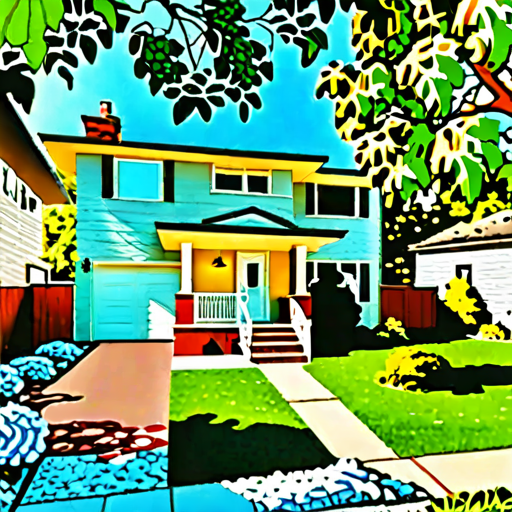

✅ ID 6 - Description: Beautiful family home in Lincoln Park. This home features a large living room, a modern kitchen, and a spacious backyard. Close to the park and local schools.
Neighborhood Description: Lincoln Park is a family-friendly neighborhood with a strong sense of community. It offers excellent schools, recreational facilities, and easy access to the city center.
Price: 600000
Bedrooms: 3
Bathrooms: 2
House Size (sqft): 1800



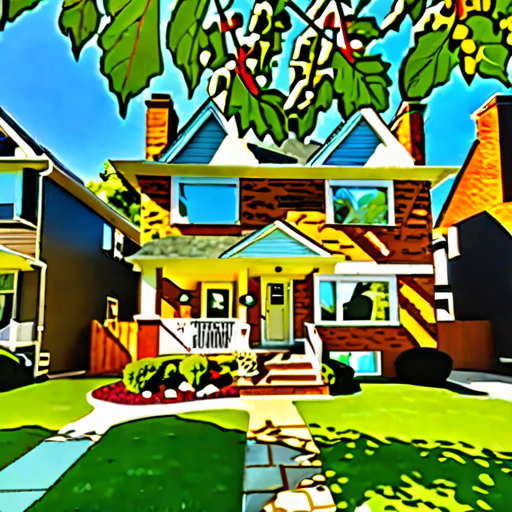

✅ ID 6 - Description: Beautiful family home in Lincoln Park. This home features a large living room, a modern kitchen, and a spacious backyard. Close to the park and local schools.
Neighborhood Description: Lincoln Park is a family-friendly neighborhood with a strong sense of community. It offers excellent schools, recreational facilities, and easy access to the city center.
Price: 600000
Bedrooms: 3
Bathrooms: 2
House Size (sqft): 1800



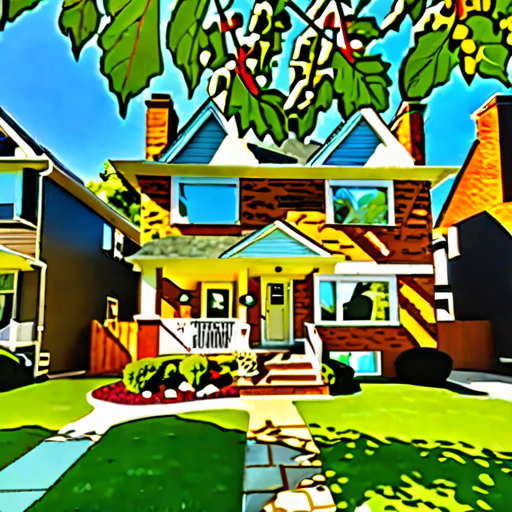

✅ ID 4 - Description: Modern condo in the South End. This home features an open floor plan, a modern kitchen with stainless steel appliances, and a private balcony. Close to the subway and local amenities.
Neighborhood Description: The South End is a vibrant neighborhood known for its diverse community, historic brownstones, and excellent restaurants. It's close to parks, schools, and public transportation.
Price: 800000
Bedrooms: 2
Bathrooms: 2
House Size (sqft): 1200



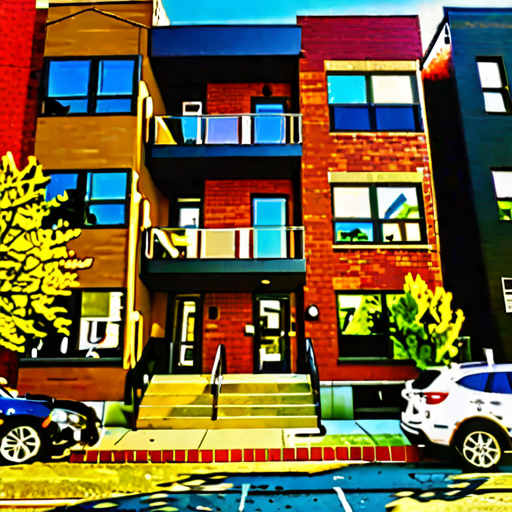

In [24]:
def multimodal_search(query_text, top_k=5):
    # 1️⃣ TEXT-BASED SEARCH
    text_results = db.similarity_search(query_text, k=top_k)

    # 2️⃣ Fetch stored images from metadata
    results = []
    for res in text_results:
        image_path = os.path.join(IMAGES_DIR, f"{res.metadata['id']}.png")

        if not os.path.exists(image_path):
            logging.warning(f"⚠️ Image file not found for ID {res.metadata['id']} at {image_path}")
            image_path = None  # Mark as missing

        results.append({
            "id": res.metadata["id"],
            "text": res.page_content,
            "image": image_path  # Attach stored image path
        })

    return results

# ✅ Example Query (No need for image embedding, just search)
buyer_query = "3-bedroom house in a quiet neighborhood with a balcony and near public transport"
search_results = multimodal_search(buyer_query)

# ✅ Display Results
print(f"🔍 Search Results for: {buyer_query}")
for res in search_results:
    print(f"✅ ID {res['id']} - {res['text']}\n")

    if res["image"]:
        display(Image.open(res["image"]))
    else:
        print(f"⚠️ Image not found for ID {res['id']}")

## **Augmented Response Generation**
We use **LLM (GPT-4)** to enhance property descriptions with a personalized touch.

📝 **Original Description:**
Description: Cozy family home in Lakeview. This home features a large living room, a modern kitchen, and a spacious backyard. Close to the lake and local parks.
Neighborhood Description: Lakeview is a family-friendly neighborhood with a strong sense of community. It offers excellent schools, recreational facilities, and easy access to the city center.
Price: 500000
Bedrooms: 3
Bathrooms: 2
House Size (sqft): 1800

✨ **Augmented Description:**
"Listing Description: Welcome to your tranquil haven in the heart of Lakeview! Nestled within a peaceful, quiet neighborhood, this charming 3-bedroom home beckons with warmth and comfort. Imagine cozying up with loved ones in the expansive living room, or hosting delightful dinner parties from your ultramodern kitchen. The large living room opens onto a private balcony where you can enjoy serenity and fresh air. The spacious backyard awaits for outdoor adventure and cherished family memories. 

Nestled near excellent pu

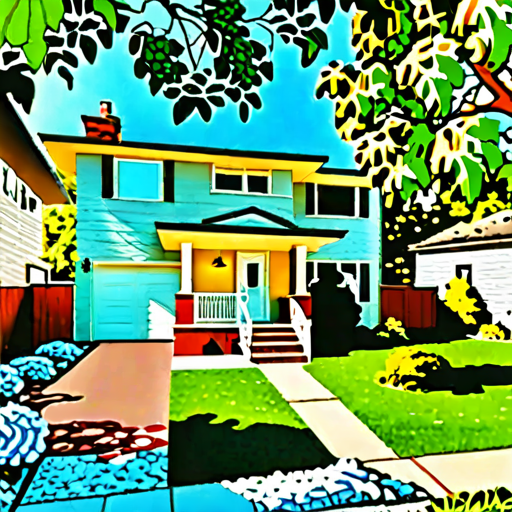

In [25]:
# Initialize LLM
llm = ChatOpenAI(model_name="gpt-4")

# Define Augmentation Function
def augment_listing_description(original_description, buyer_query):
    prompt = f"""
    You are a real estate expert. Based on the buyer's preferences:
    "{buyer_query}"

    Improve the following listing description to make it more appealing and tailored:
    "{original_description}"

    Make it engaging but keep all factual information unchanged.
    """
    return llm.invoke(prompt).content

# Enhance the top search result
if results:
    best_listing = results[0]
    original_desc = best_listing["text"]
    augmented_desc = augment_listing_description(original_desc, buyer_query)

    print(f"📝 **Original Description:**\n{original_desc}\n")
    print(f"✨ **Augmented Description:**\n{augmented_desc}")

    # Display the image for the top result
    display(Image.open(best_listing["image"]))

# Gradio User Interface

In [29]:
import gradio as gr
import pandas as pd
import os
from PIL import Image

# ✅ Constants
IMAGES_DIR = "images"
LISTINGS_CSV = "listings.csv"

# ✅ Load Listings Data
try:
    df = pd.read_csv(LISTINGS_CSV)
except FileNotFoundError:
    raise FileNotFoundError(f"🚨 ERROR: {LISTINGS_CSV} not found!")

# ✅ Define Buyer Questions
QUESTIONS = [
    "What is your budget range?",
    "How many bedrooms do you need?",
    "Do you prefer a specific neighborhood?",
    "Any must-have features? (e.g., balcony, garden, garage)",
    "What type of property do you prefer? (e.g., apartment, villa, townhouse)"
]

# ✅ Function to Perform Search Based on Buyer Preferences
def search_listings(budget, bedrooms, neighborhood, features, property_type):
    buyer_query = f"{bedrooms}-bedroom {property_type} in {neighborhood} with {features} under {budget}"

    # 🔍 Perform search in the vector database
    results = db.similarity_search(buyer_query, k=6)

    # 🔹 Extract matching listing details
    listings = []
    for res in results:
        listing_id = int(res.metadata["id"])
        image_path = os.path.join(IMAGES_DIR, f"{listing_id}.png")

        if os.path.exists(image_path):
            listings.append((image_path, df.iloc[listing_id]["neighborhood"]))

    return listings if listings else [("No results found", "")]

# ✅ Function to Personalize Listing Description
def personalize_description(evt: gr.SelectData):
    listing_id = int(evt.value.split('/')[-1].split('.')[0])  # Extract ID from filename
    return df.iloc[listing_id]["description"]

# ✅ Create Gradio UI
def create_ui():
    with gr.Blocks() as demo:
        gr.Markdown("## 🏡 HomeMatch: Your Personalized Real Estate Search")

        with gr.Tabs():
            with gr.TabItem("Buyer's Preferences"):
                with gr.Row():
                    answers = [gr.Textbox(label=q) for q in QUESTIONS]
                search_btn = gr.Button("Find My Home 🏠")

            with gr.TabItem("Search Results"):
                with gr.Row():
                    gallery = gr.Gallery(label="Recommended Listings", columns=3, rows=2, allow_preview=True)
                with gr.Row():
                    personalized_desc = gr.Textbox(label="Personalized Description", interactive=False)

        # ✅ Event Handlers
        search_btn.click(
            fn=search_listings,
            inputs=answers,
            outputs=gallery
        )

        gallery.select(
            fn=personalize_description,
            inputs=None,
            outputs=personalized_desc
        )

    return demo

In [30]:
# ✅ Launch Application
if __name__ == "__main__":
    demo = create_ui()
    demo.launch()

Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
IMPORTANT: You are using gradio version 4.19.2, however version 4.44.1 is available, please upgrade.
--------
Running on public URL: https://642a5ecff47c2e4590.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
